In [2]:
#Bibliotecas para operações numéricas
import numpy as np

#Para vizualização
import matplotlib.pyplot as plt

#Para redes neurais
import tensorflow as tf

#interface de alto nível para construir redes neurais
from tensorflow import keras

#importando o módulo de camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

#Funções utilitarias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

Carregar base CIFAR-10

In [3]:
# Carregar a base CIFAR
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

classe_names = ['avião', 'automóvel', 'pássaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

print(f'Formato do x_train: {x_train.shape}')
print(f'Formato do x_test: {x_test.shape}')
print(f'Formato do y_train: {y_train.shape}')
print(f'Formato do y_test: {y_test.shape}')


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 94s 1us/step
Formato do x_train: (50000, 32, 32, 3)
Formato do x_test: (10000, 32, 32, 3)
Formato do y_train: (50000,)
Formato do y_test: (10000,)


Plotar Algumas Imagens

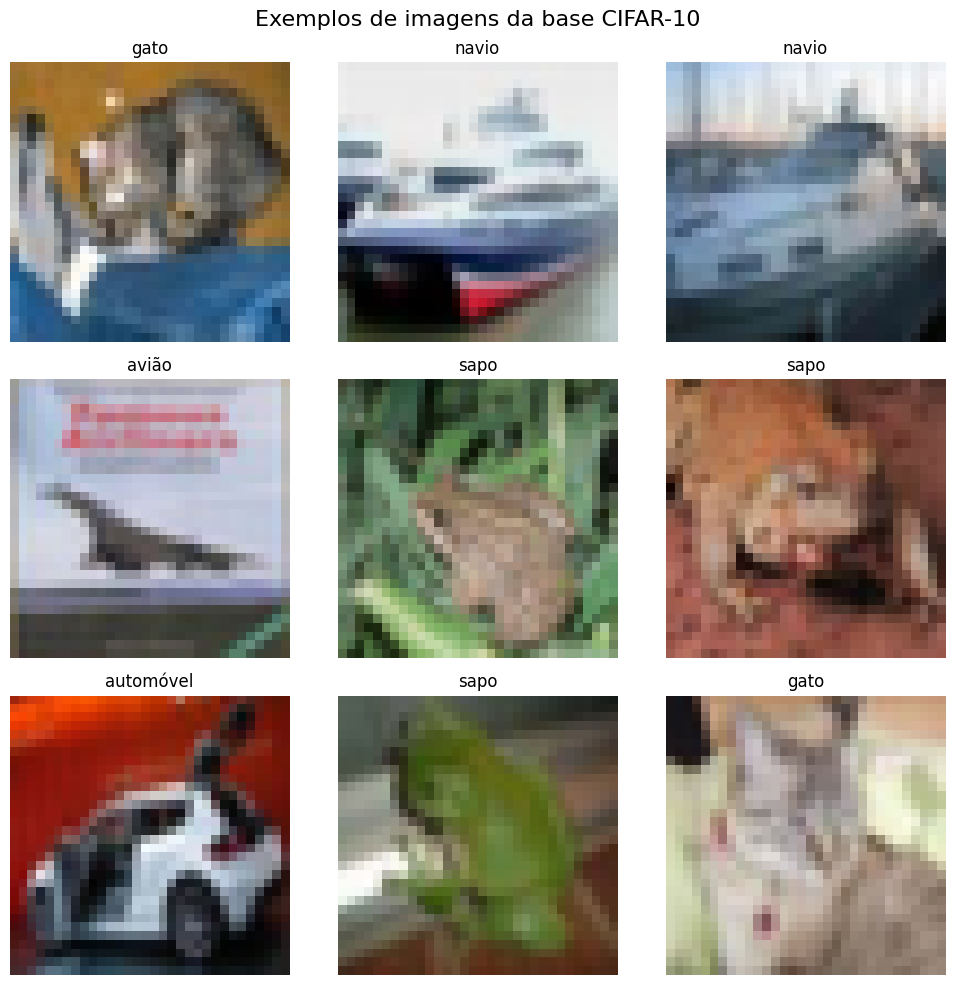

In [6]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    plt.title(classe_names[y_test[i]])
    plt.axis('off')
plt.suptitle('Exemplos de imagens da base CIFAR-10', fontsize=16)
plt.tight_layout()
plt.show()


Criação do Modelo CNN

In [8]:
model = keras.Sequential()

# Camada de entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#Transmissão CNN -> Dense (Totalmente conectada)
model.add(Flatten())
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=10, activation='softmax'))


# Compilar
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#Resumo da arquitetura de modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

Treinar a Rede

In [9]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3726 - loss: 1.7158 - val_accuracy: 0.4567 - val_loss: 1.5053
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5062 - loss: 1.3764 - val_accuracy: 0.5366 - val_loss: 1.2953
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5617 - loss: 1.2325 - val_accuracy: 0.5767 - val_loss: 1.1989
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5944 - loss: 1.1485 - val_accuracy: 0.5961 - val_loss: 1.1401
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6211 - loss: 1.0770 - val_accuracy: 0.5976 - val_loss: 1.1369
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6426 - loss: 1.0218 - val_accuracy: 0.6332 - val_loss: 1.0497
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6608 - loss: 0.9670 - val_accuracy: 0.6440 - val_loss: 1.0213
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6760 - loss: 0.9270 - val_accuracy: 0.

Plot da Acurácia e Loss

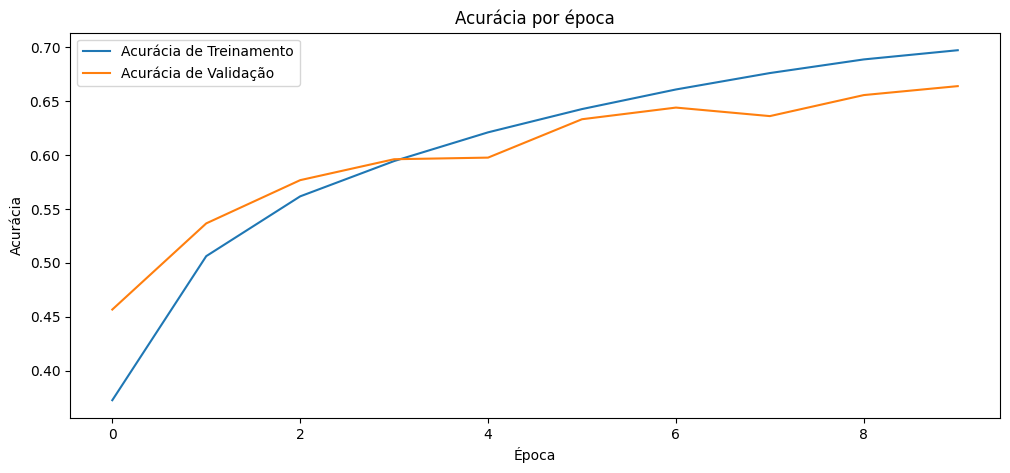

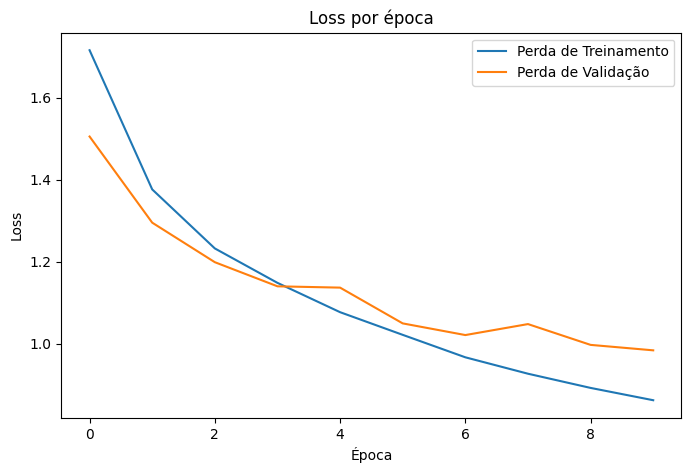

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia por época')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss por época')
plt.legend()
plt.show()